### Required Libraries

In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn streamlit plotly

### Import Libraries

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

### Load Dataset

In [7]:
df = pd.read_csv(
    "APL_Logistics_.csv",
    encoding='latin1'
)

print(df.shape)

df.head()

(180519, 40)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


### Basic EDA

In [8]:
print(df.info())

print(df.isnull().sum())

print(df['Late_delivery_risk'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

##### Target Variable Distribution

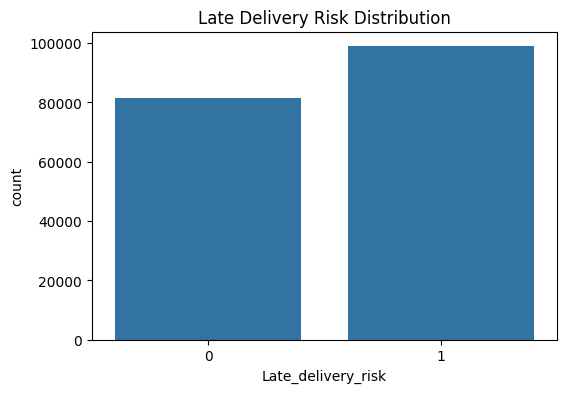

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Late_delivery_risk',
    data=df
)

plt.title("Late Delivery Risk Distribution")

plt.show()

### Feature Engineering

##### Shipping Pressure Index

In [10]:
df['Shipping_Pressure_Index'] = (
    df['Order Item Quantity']
    /
    (df['Days for shipment (scheduled)'] + 1)
)

##### Delivery Gap

In [11]:
df['Delivery_Gap'] = (
    df['Days for shipping (real)']
    -
    df['Days for shipment (scheduled)']
)

##### Order Complexity Score

In [12]:
df['Order_Complexity_Score'] = (
    df['Order Item Quantity']
    *
    df['Order Item Product Price']
)

##### Express Shipping Flag

In [13]:
df['Express_Flag'] = np.where(
    df['Shipping Mode'].str.contains(
        'First|Same Day',
        case=False,
        na=False
    ),
    1,
    0
)

##### Regional Congestion Score

In [14]:
region_delay = (
    df.groupby('Order Region')['Late_delivery_risk']
    .mean()
)

df['Regional_Congestion'] = (
    df['Order Region']
    .map(region_delay)
)

### Drop Leakage Columns

In [15]:
leakage_cols = [

    'Delivery Status',
    'Days for shipping (real)'
]

df = df.drop(
    columns=leakage_cols,
    errors='ignore'
)

### Separate Features & Target

In [16]:
X = df.drop(
    'Late_delivery_risk',
    axis=1
)

y = df['Late_delivery_risk']

### Identify Numerical & Categorical Columns

In [17]:
categorical_cols = X.select_dtypes(
    include=['object']
).columns

numerical_cols = X.select_dtypes(
    exclude=['object']
).columns

### Preprocessing Pipeline

In [18]:
numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numerical_cols
        ),
        (
            'cat',
            categorical_transformer,
            categorical_cols
        )
    ]
)

### Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Transform Data

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

### Handle Class Imbalance

In [21]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print(y_train_smote.value_counts())

Late_delivery_risk
1    79181
0    79181
Name: count, dtype: int64


### Logistic Regression

In [22]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = lr_model.predict(X_test_processed)

lr_prob = lr_model.predict_proba(
    X_test_processed
)[:,1]

### Evaluation Function

In [23]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    print("\n")
    print(model_name)

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_true,
            y_pred
        )
    )

    print(
        "ROC AUC:",
        roc_auc_score(
            y_true,
            y_prob
        )
    )

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

In [24]:
evaluate_model(
    y_test,
    lr_pred,
    lr_prob,
    "Logistic Regression"
)



Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0
[[16308     0]
 [    0 19796]]


### Random Forest

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

rf_pred = rf_model.predict(
    X_test_processed
)

rf_prob = rf_model.predict_proba(
    X_test_processed
)[:,1]

evaluate_model(
    y_test,
    rf_pred,
    rf_prob,
    "Random Forest"
)



Random Forest
Accuracy: 0.9261854642144914
Precision: 0.9256149068322982
Recall: 0.9409981814507982
F1 Score: 0.9332431552315824
ROC AUC: 0.9774318851896903
[[14811  1497]
 [ 1168 18628]]


### XGBoost

In [26]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

xgb_pred = xgb_model.predict(
    X_test_processed
)

xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:,1]

evaluate_model(
    y_test,
    xgb_pred,
    xgb_prob,
    "XGBoost"
)



XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0
[[16308     0]
 [    0 19796]]


### Feature Importance

In [27]:
feature_names = (
    preprocessor.get_feature_names_out()
)

importance = pd.DataFrame({

    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print(
    importance.head(20)
)

                                                 Feature    Importance
20                                     num__Delivery_Gap  8.457441e-01
14792                  cat__Order Status_SUSPECTED_FRAUD  8.060443e-02
14784                         cat__Order Status_CANCELED  7.340192e-02
14791                       cat__Order Status_PROCESSING  1.471899e-04
14789                          cat__Order Status_PENDING  5.216140e-05
27                                    cat__Type_TRANSFER  3.798704e-05
14911                     cat__Shipping Mode_First Class  5.816390e-06
14914                  cat__Shipping Mode_Standard Class  5.482871e-06
22                                     num__Express_Flag  6.664250e-07
0                     num__Days for shipment (scheduled)  1.260351e-07
19                          num__Shipping_Pressure_Index  4.335061e-08
7                                          num__Latitude  3.480512e-08
2516                      cat__Customer Segment_Consumer  2.120092e-08
10    

##### Vizualization

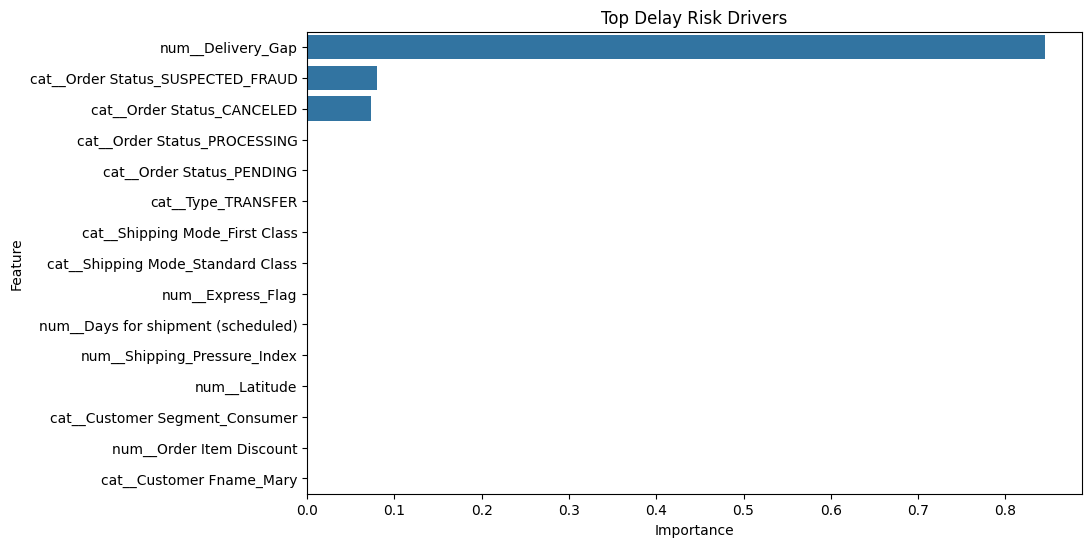

In [28]:
plt.figure(
    figsize=(10,6)
)

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top Delay Risk Drivers"
)

plt.show()

### Risk Classification

In [29]:
risk_scores = xgb_model.predict_proba(
    X_test_processed
)[:,1]

In [30]:
risk_df = X_test.copy()

risk_df['Risk_Probability'] = risk_scores

In [31]:
def classify_risk(prob):

    if prob < 0.30:
        return "Low Risk"

    elif prob < 0.70:
        return "Medium Risk"

    else:
        return "High Risk"

In [32]:
risk_df['Risk_Category'] = (
    risk_df['Risk_Probability']
    .apply(classify_risk)
)

### High Risk Orders

In [33]:
high_risk_orders = risk_df[
    risk_df['Risk_Category']
    == 'High Risk'
]

print(
    high_risk_orders.head()
)

            Type  Days for shipment (scheduled)  Benefit per order  \
107905   PAYMENT                              4              84.47   
153004  TRANSFER                              4              53.95   
149022   PAYMENT                              2              34.40   
3231    TRANSFER                              4              30.94   
1578       DEBIT                              1             -69.72   

        Sales per customer  Category Id         Category Name Customer City  \
107905              263.98           43      Camping & Hiking     Fullerton   
153004              165.99           48          Water Sports        Caguas   
149022              122.84           18        Men's Footwear      Columbus   
3231                 91.00           24       Women's Apparel      Mililani   
1578                139.44           46  Indoor/Outdoor Games         Bronx   

       Customer Country Customer Fname  Customer Id  ...  \
107905          EE. UU.         Edward      

### Save Model

In [35]:
import joblib

joblib.dump(
    xgb_model,
    "xgb_model.pkl"
)

joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print("Model Saved")

Model Saved
